In [ ]:
!pip install langchain-community
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.0/444.0 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 4.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 0.3.74
    Uninstalling langchain-core-0.3.74:
      Successfully uninstalled langchain-core-0.3.74
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 310.5/310.5 kB 4.8 

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from langchain.document_loaders import PyPDFLoader


def processar_pdf(path : str):
  loader = PyPDFLoader(path)
  docs = loader.load()
  doc_string = """"""
  for doc in docs:
    doc_string += doc.page_content
  return doc_string


In [ ]:
dificuldades = {}


for ano in range(2019, 2024):
  fases = {"fase1" : {},
         "fase2" : {},
         "fase3" : {}}
  for fase in range(1, 4):

    if ano == 2019 and fase == 3:
      continue
    path = f"/content/drive/MyDrive/PROVAS PROCESSADAS/Parâmetro 2/OCHE{ano}[{fase}] - Parâmetro 2.pdf"
    prova = processar_pdf(path).lower().strip()
    fases[f"fase{fase}"]["fáceis"] = prova.count("dificuldade:  fácil")
    fases[f"fase{fase}"]["médias"] = prova.count("dificuldade:  média")
    fases[f"fase{fase}"]["difíceis"] = prova.count("dificuldade:  difícil")
  dificuldades[ano] = fases.copy()

print(dificuldades)

def processar_dicionario(dicionario_entrada : dict, dicionario_destino : dict):
  for key in dicionario_entrada.keys():
    if not key in dicionario_destino:
      dicionario_destino[key] = 0
    else:
      dicionario_destino[key] += dicionario_entrada[key]

dificuldades_gerais = {}
for ano in range(2019, 2024):
  for fase in range(1, 4):
    processar_dicionario(dificuldades[ano][f"fase{fase}"], dificuldades_gerais)

print(dificuldades_gerais)


{2019: {'fase1': {'fáceis': 2, 'médias': 8, 'difíceis': 5}, 'fase2': {'fáceis': 1, 'médias': 10, 'difíceis': 4}, 'fase3': {}}, 2020: {'fase1': {'fáceis': 2, 'médias': 4, 'difíceis': 4}, 'fase2': {'fáceis': 1, 'médias': 2, 'difíceis': 7}, 'fase3': {'fáceis': 2, 'médias': 5, 'difíceis': 3}}, 2021: {'fase1': {'fáceis': 0, 'médias': 7, 'difíceis': 3}, 'fase2': {'fáceis': 0, 'médias': 6, 'difíceis': 4}, 'fase3': {'fáceis': 0, 'médias': 7, 'difíceis': 3}}, 2022: {'fase1': {'fáceis': 0, 'médias': 6, 'difíceis': 4}, 'fase2': {'fáceis': 0, 'médias': 7, 'difíceis': 3}, 'fase3': {'fáceis': 0, 'médias': 8, 'difíceis': 2}}, 2023: {'fase1': {'fáceis': 0, 'médias': 6, 'difíceis': 4}, 'fase2': {'fáceis': 0, 'médias': 6, 'difíceis': 4}, 'fase3': {'fáceis': 0, 'médias': 10, 'difíceis': 0}}}
{'fáceis': 6, 'médias': 84, 'difíceis': 45}


In [ ]:
def plotar_grafico(dificuldades : dict, ano : int):
  x = np.arange(3)
  largura = 0.25
  plt.figure(figsize=(8, 6))
  dificuldades_ano = dificuldades[ano]
  phases_to_plot = [f"fase{i}" for i in range(1, 4) if f"fase{i}" in dificuldades_ano and dificuldades_ano[f"fase{i}"]] # Check if the phase exists and is not empty

  if len(phases_to_plot) == 2:
    plt.bar(x - largura/2, list(dificuldades_ano[phases_to_plot[0]].values()), width=largura, label='Primeira Fase')
    plt.bar(x + largura/2, list(dificuldades_ano[phases_to_plot[1]].values()), width=largura, label='Segunda Fase')
  elif len(phases_to_plot) == 3:
    plt.bar(x - largura, list(dificuldades_ano[phases_to_plot[0]].values()), width=largura, label='Primeira Fase')
    plt.bar(x, list(dificuldades_ano[phases_to_plot[1]].values()), width=largura, label='Segunda Fase')
    plt.bar(x + largura, list(dificuldades_ano[phases_to_plot[2]].values()), width=largura, label='Terceira Fase')
  else:
    print(f"No data to plot for year {ano}")


  plt.xlabel('Dificuldade')
  plt.ylabel('Quantidade')
  plt.title(f'Quantidade de Questões por Dificuldade - OCHE{ano}')
  plt.xticks(x, ['Fácil', 'Média', 'Difícil'])
  plt.legend()
  plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plotar_grafico(dados, ano):
    # Verifica se o ano existe no dicionário
    if ano not in dados:
        print(f"Ano {ano} não encontrado nos dados.")
        return

    fases = list(dados[ano].keys())
    dificuldades = ["fáceis", "médias", "difíceis"]

    # Paleta de cores mais escuras
    cores = {
        "fáceis": "#1f3b73",   # azul escuro
        "médias": "#145a32",   # verde escuro
        "difíceis": "#e67e22"  # laranja escuro
    }

    # Montando matriz de valores
    valores = []
    for dificuldade in dificuldades:
        linha = []
        for fase in fases:
            linha.append(dados[ano][fase].get(dificuldade, 0))  # se faltar chave, assume 0
        valores.append(linha)

    # Configurações para barras lado a lado
    x = np.arange(len(fases))
    largura = 0.25

    fig, ax = plt.subplots(figsize=(10, 6))

    for i, dificuldade in enumerate(dificuldades):
        ax.bar(x + i*largura, valores[i], width=largura,
               label=dificuldade.capitalize(), color=cores[dificuldade])

    # Ajustando eixo X e rótulos
    ax.set_xticks(x + largura)
    ax.set_xticklabels(fases)
    ax.set_ylabel("Quantidade de Questões")
    ax.set_title(f"Distribuição de Questões por Fase ({ano})")
    ax.legend()
    plt.show()


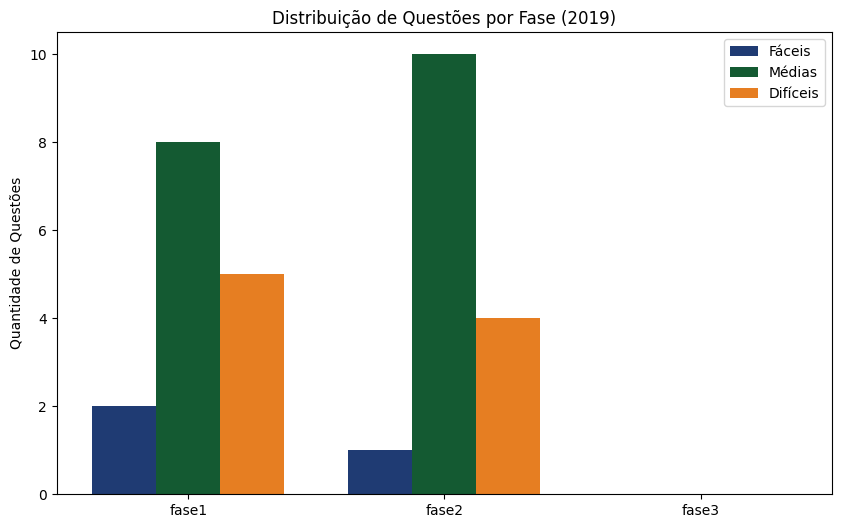

In [ ]:
plotar_grafico(dificuldades, 2019)

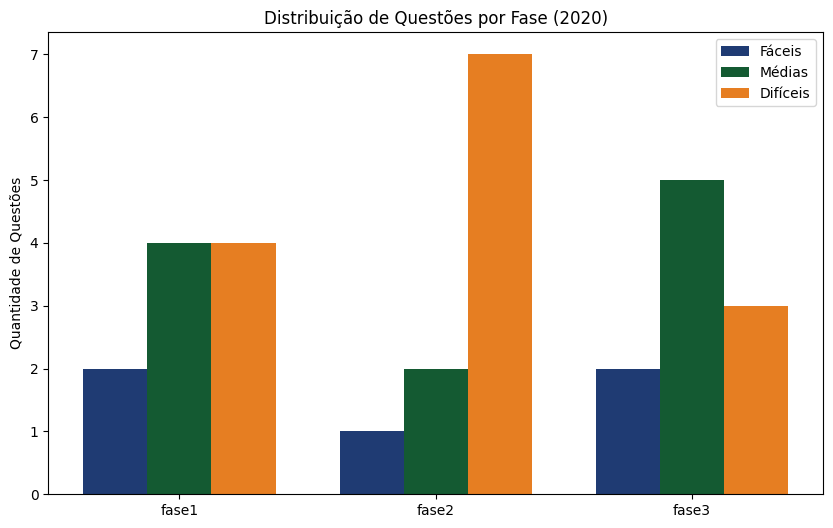

In [ ]:
plotar_grafico(dificuldades,2020)

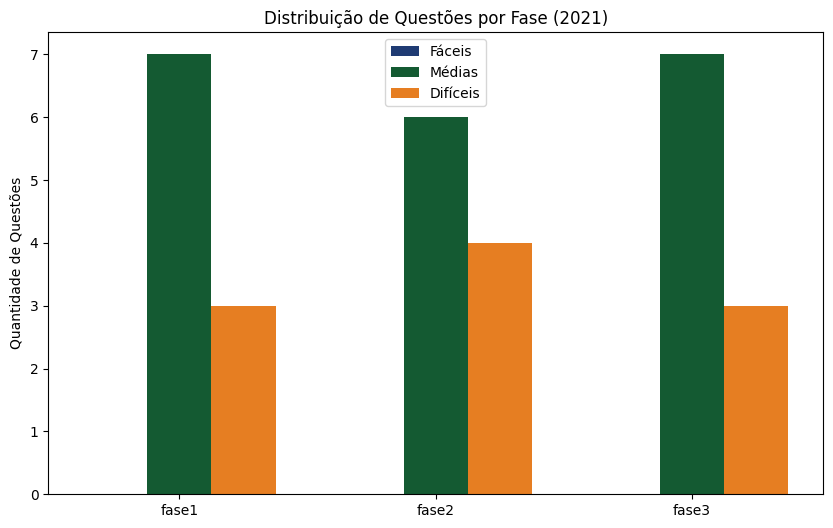

In [ ]:
plotar_grafico(dificuldades, 2021)

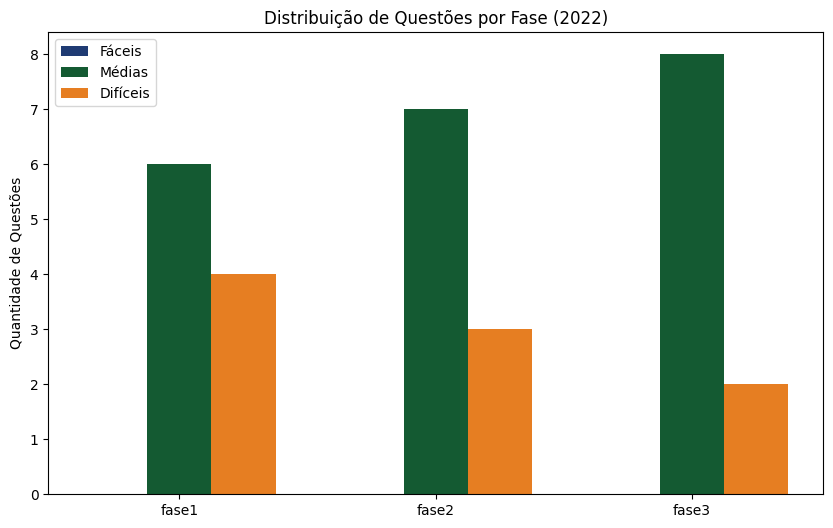

In [ ]:
plotar_grafico(dificuldades, 2022)

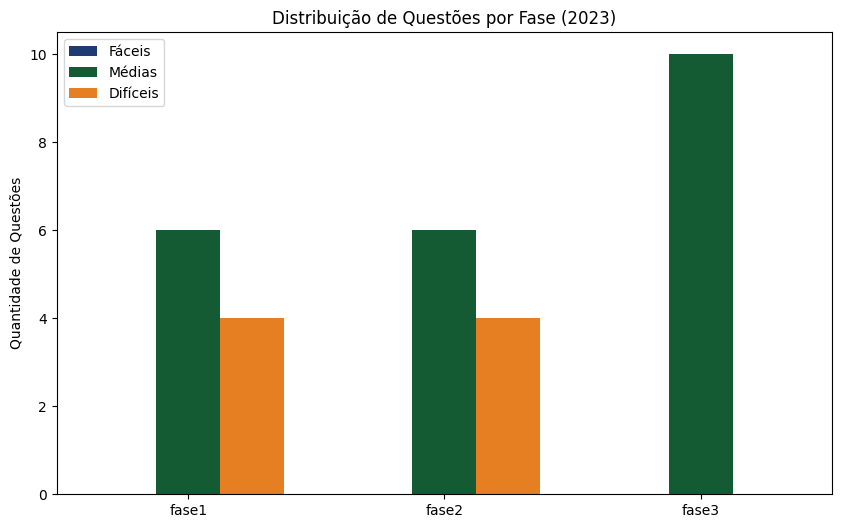

In [ ]:
plotar_grafico(dificuldades, 2023)